In [1]:
import glob, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import signal, stats
from scipy.stats import t, sem, zscore
from scipy.ndimage import gaussian_filter1d
import pickle
import h5py
import warnings
import random
import matplotlib as mpl
import networkx as nx
from collections import Counter
warnings.simplefilter('ignore')

In [2]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['xtick.minor.visible'] = False
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.width'] = 0.5
mpl.rcParams['ytick.minor.visible'] =False
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.edgecolor']='black'
mpl.rcParams['figure.dpi'] = 80
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize']=10
mpl.rcParams['axes.titlesize']=10
mpl.rcParams['legend.fontsize']=10
mpl.rcParams['xtick.labelsize']=10
mpl.rcParams['ytick.labelsize']=10
mpl.rcParams['text.color']='black'
mpl.rcParams['lines.color']='black'
mpl.rcParams['xtick.color']='black'
mpl.rcParams['ytick.color']='black'
mpl.rcParams['axes.labelcolor']='black'

# Load data

In [3]:
codeDir = '/mnt/ssd1/ysaito/with_Uwamori/00_code/LCCD-ver3-main'
dataDir = os.getcwd().replace('02_analysis', '01_data')
analysisDir = os.getcwd()
fs= 7.65

In [4]:
dF_F_path = glob.glob(analysisDir+'/01_ROI_detection/ver_3/04_signal_extraction/dF_F.mat')[0]
ROI_metrics_path = glob.glob(analysisDir+'/01_ROI_detection/ver_3/05_calculate_metrics/ROI_metrics.mat')[0]

In [5]:
with h5py.File(dF_F_path, 'r') as f:
    # Navigate to your dataset "dF_F"
    cell_data = f["dF_F"]
    dF_F = np.array(cell_data).T

In [6]:
with h5py.File(ROI_metrics_path, 'r') as f:
    ROI_metircs_h5 = f["ROI_metrics"]
    ROI_metrics={}
    for i in ROI_metircs_h5.keys():
        ROI_metrics.update({i:np.array(list(ROI_metircs_h5[i]))})

In [7]:
# Using cell ROIs
CellUse = np.where(ROI_metrics['CellUse'][0]==1)[0]
NeuronNum = CellUse.shape[0]

In [8]:
NeuronNum

7685

In [9]:
cell_dF_F = dF_F[CellUse]
cell_centroid = ROI_metrics['Centroid'][:,CellUse].T

In [10]:
outputDir = analysisDir+'/02_Deconvolution'
os.makedirs(outputDir, exist_ok=True)

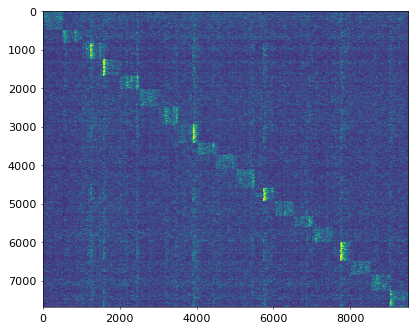

In [11]:
plt.imshow(cell_dF_F, vmin=0, vmax=1)

# Baseline collection

In [12]:
def baseline_corr(F, fs, baseline='maximin', sig_baseline = 10, win_baseline=60, prctile_baseline=15):
    '''
    From suite2p
    sig_baseline:in bins, standard deviation of gaussian with which to smooth
    win_baseline:in seconds, window in which to compute max/min filters
    '''
    from scipy.ndimage import maximum_filter1d, minimum_filter1d, gaussian_filter, percentile_filter
    win = int(win_baseline * fs)
    if baseline == "maximin":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = minimum_filter1d(Flow, win)
        Flow = maximum_filter1d(Flow, win)
    elif baseline == "constant":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = np.amin(Flow)
    elif baseline == "constant_prctile":
        Flow = np.percentile(F, prctile_baseline, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    elif baseline == "percentile":
        Flow = percentile_filter(F, percentile=prctile_baseline, size=win, axes=1)
    elif baseline == "constant_median":
        Flow = np.median(F, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    Fcorr = F - Flow
    
    return Fcorr

In [13]:
def plot_res_baseline_correction(time, dF_F, corrected_dF_F, cellID):
    plt.figure(figsize=(16,5), tight_layout=True)
    plt.subplot(311)
    plt.plot(time, dF_F[cellID], lw=1, c='black', label='cellID: '+str(cellID)+' before correction')
    plt.xlim(0,time.max())
    plt.legend(loc=(.02,.9), frameon=False)
    plt.subplot(312)
    plt.plot(time, corrected_dF_F[cellID], lw=1, c='gray', label='cellID: '+str(cellID)+' baseline corrected')
    plt.xlim(0,time.max())
    plt.ylabel('dF/F0')
    plt.legend(loc=(.02,.9), frameon=False)
    plt.subplot(313)
    plt.plot(time, dF_F[cellID], lw=1, c='black')
    plt.plot(time, corrected_dF_F[cellID], lw=1, c='gray')
    plt.xlim(0,time.max())
    sns.despine()
    plt.xlabel('Time (sec)')
    

In [14]:
time=np.arange(0, dF_F.shape[1], 1)/fs
corrected_dF_F = baseline_corr(cell_dF_F, fs=fs, baseline='maximin', sig_baseline=10, win_baseline=15)

In [15]:
np.random.seed(seed=0)
cellID = np.random.choice(np.arange(0,corrected_dF_F.shape[0]), size=10, replace=False)

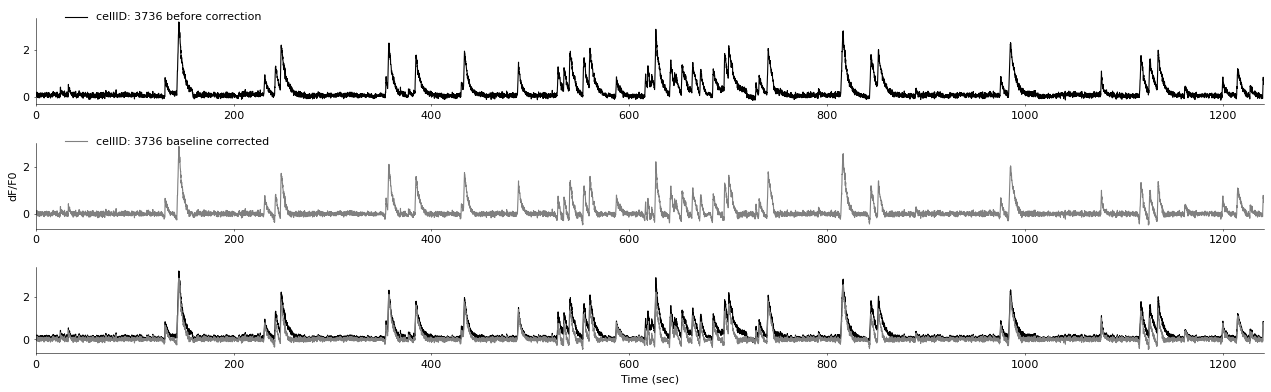

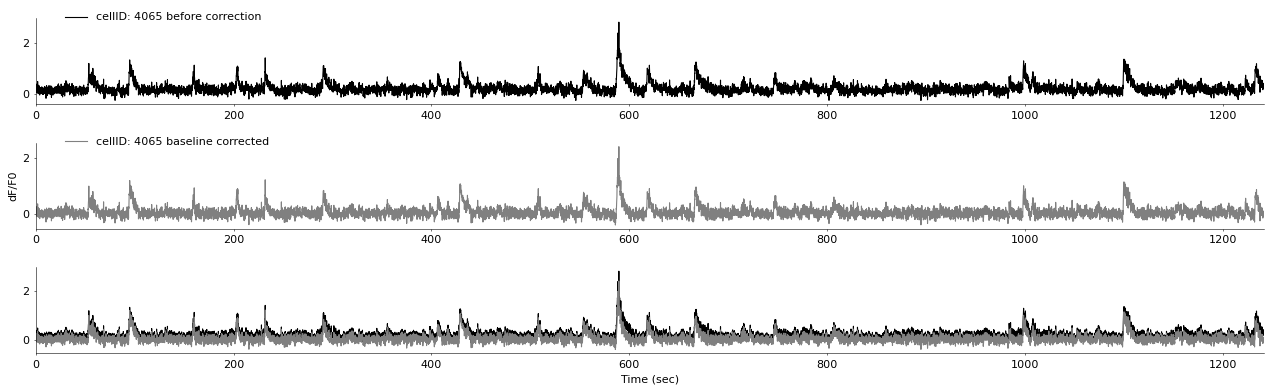

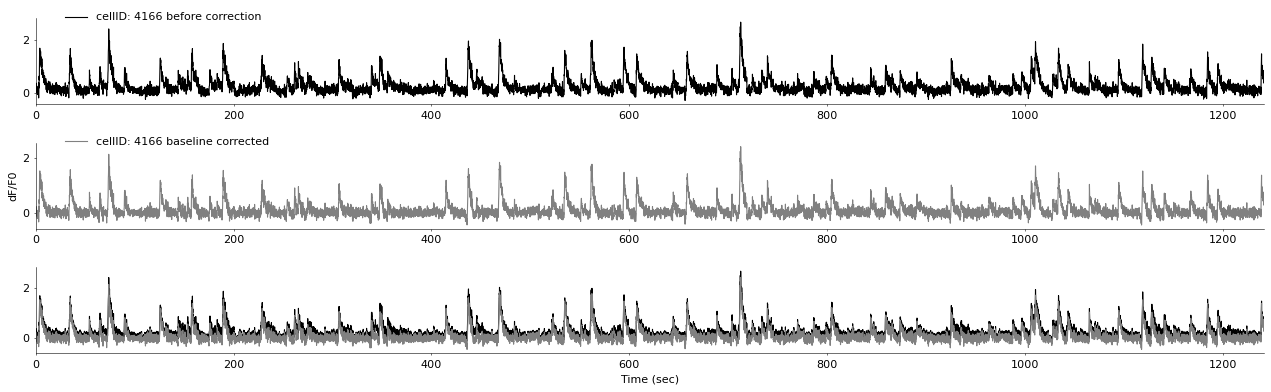

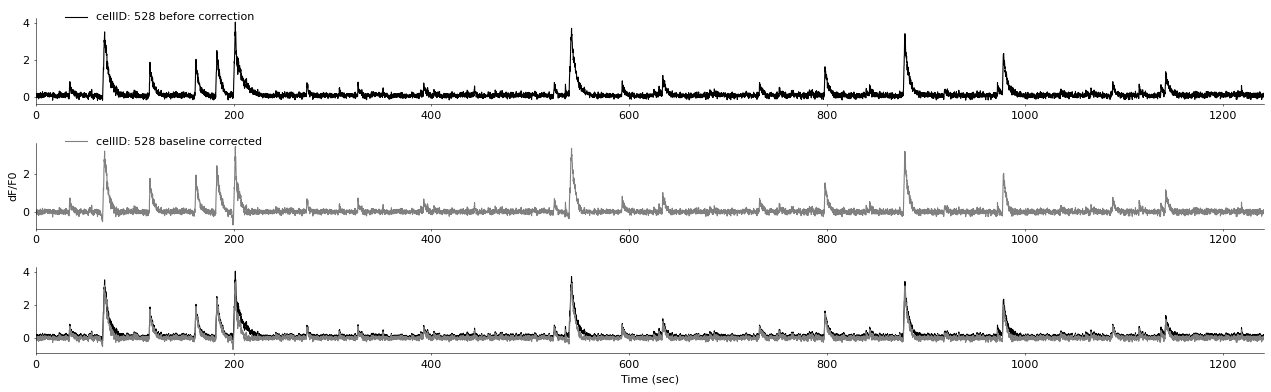

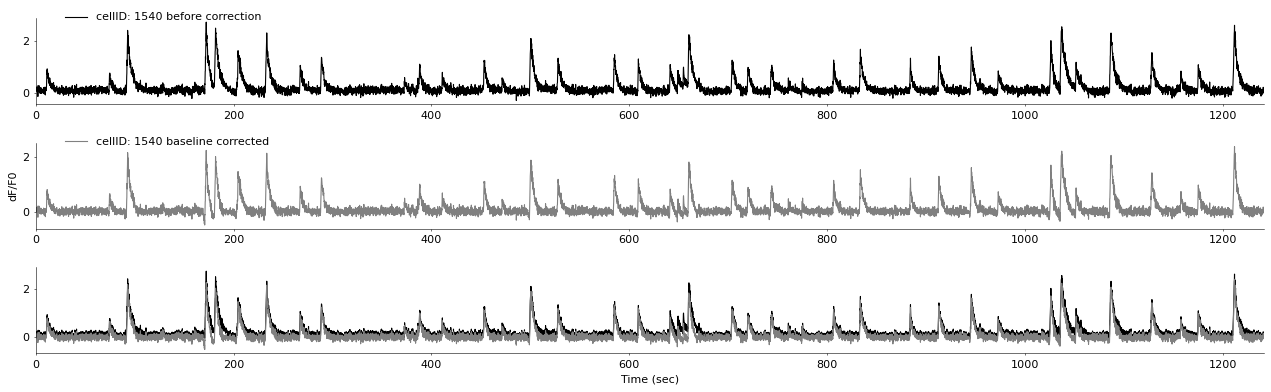

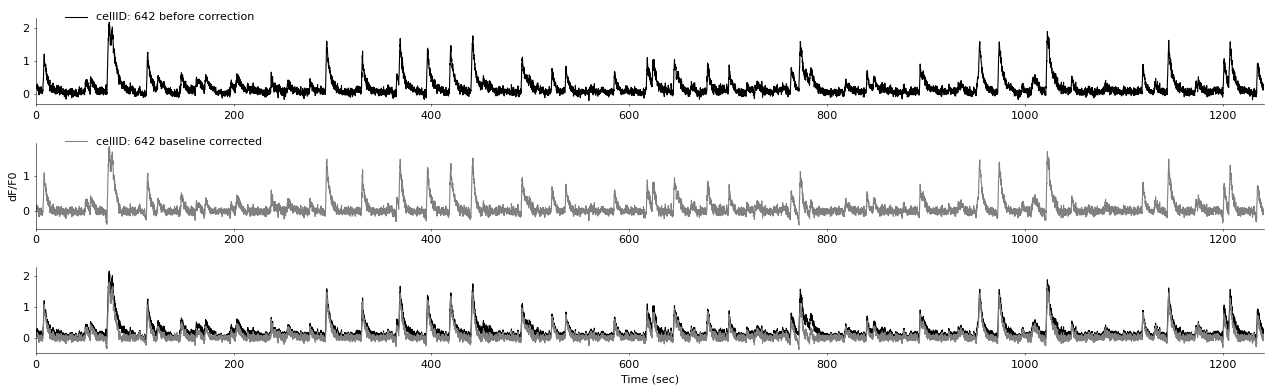

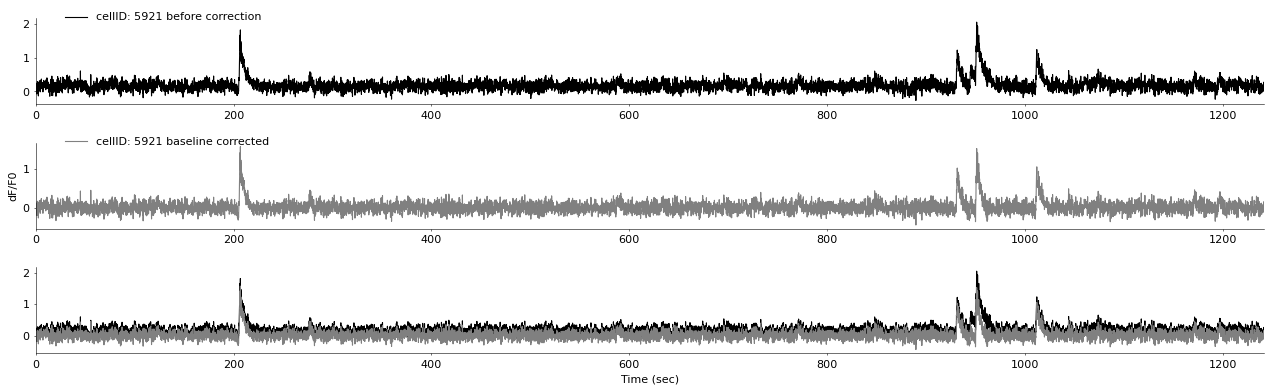

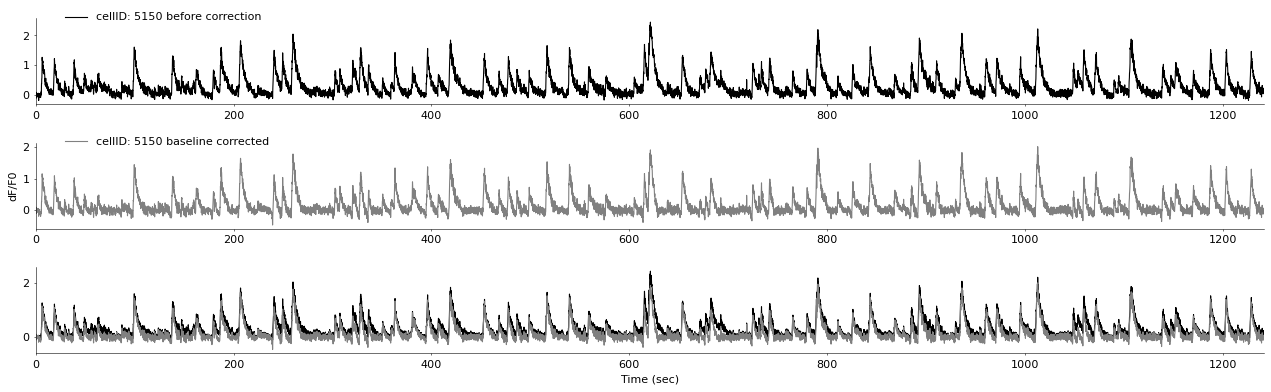

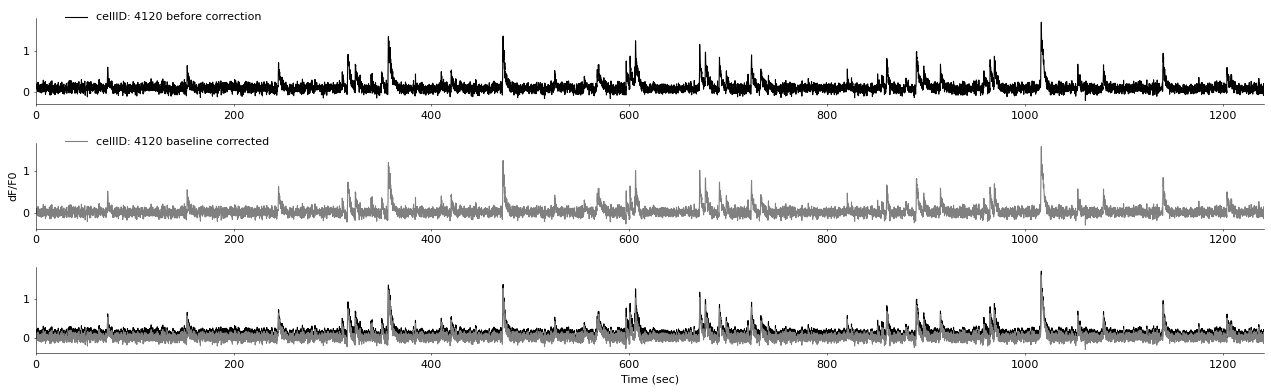

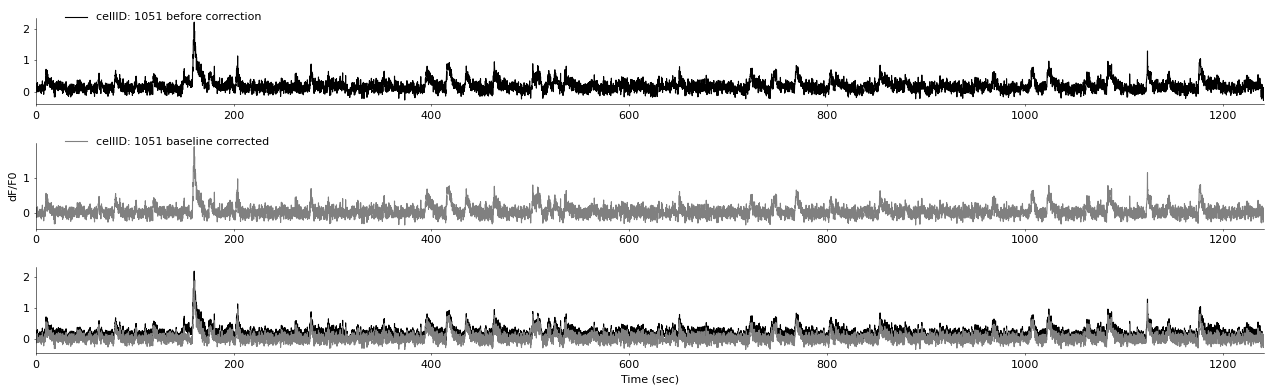

In [16]:
for i in cellID:
    plot_res_baseline_correction(time, cell_dF_F, corrected_dF_F, cellID=i)

# Deconvolution

In [17]:
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2

In [18]:
def plot_trace(time, dF_F, c, s, xwindow=[0, 1000]):
    plt.figure(figsize=(16,5), tight_layout=True)
    plt.subplot(311)
    plt.plot(time, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    plt.ylim(-0.5,4)
    simpleaxis(plt.gca())
    
    plt.subplot(312)
    plt.plot(time, c, lw=2, label='denoised')
    plt.plot(time, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    plt.ylim(-0.5,4)
    simpleaxis(plt.gca())
    
    plt.subplot(313)
    plt.plot(time, s, lw=2, label='deconvolved', c='g')
    plt.ylim(0,1.5)
    plt.legend(ncol=3, frameon=False, loc=(.02,.9));
    simpleaxis(plt.gca())
    plt.xlim(xwindow[0], xwindow[1])
    plt.xlabel('Time (sec)')
    
    plt.subplots_adjust(wspace=0.4, hspace=0.6)

In [19]:
#### If the baseline is still high after slow drift correction, the baseline is aligned by subtracting MEDIAN.
corrected_dF_F = baseline_corr(corrected_dF_F, fs=fs, baseline='constant_median')

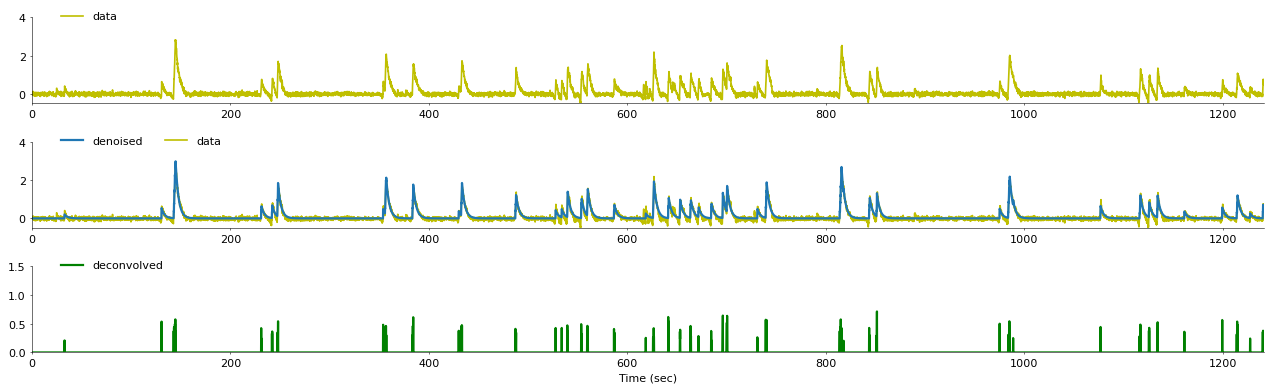

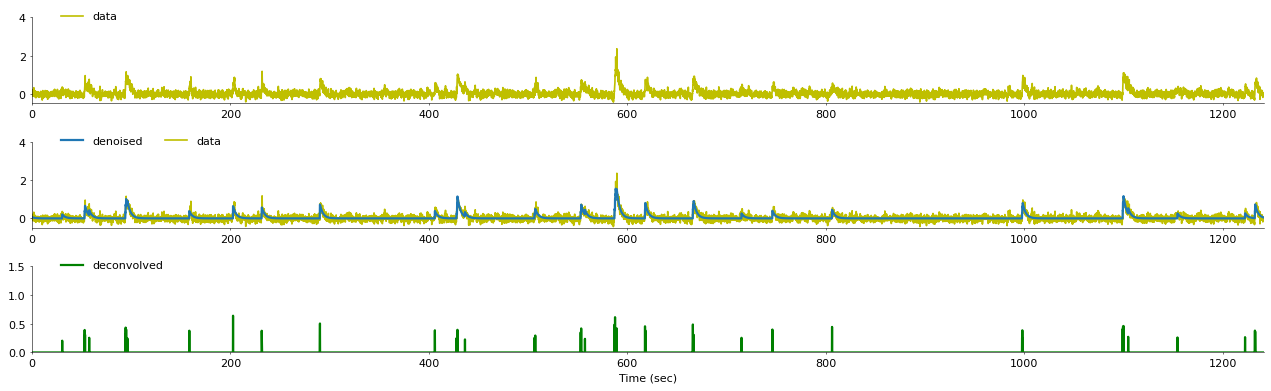

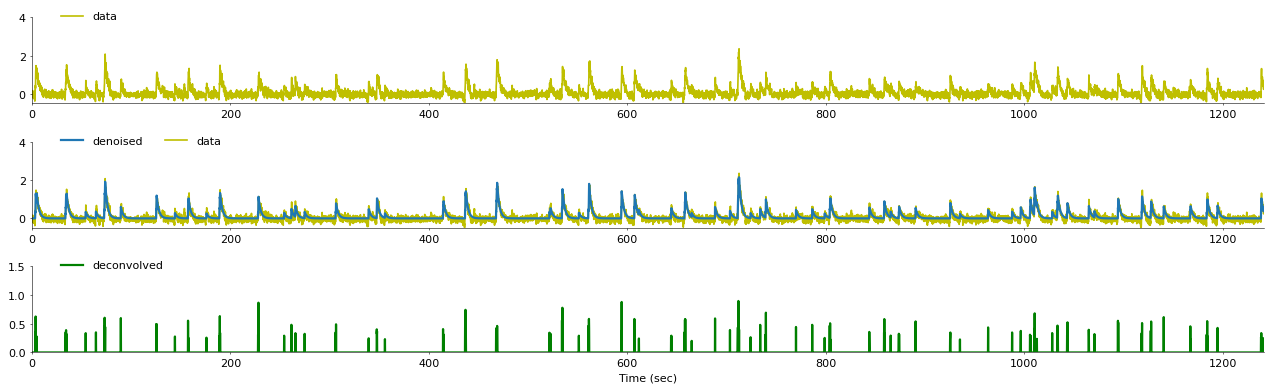

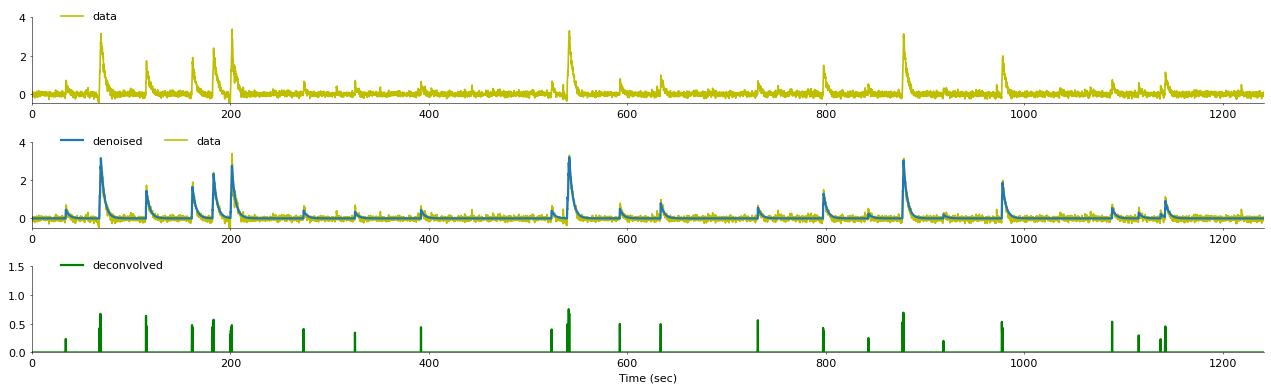

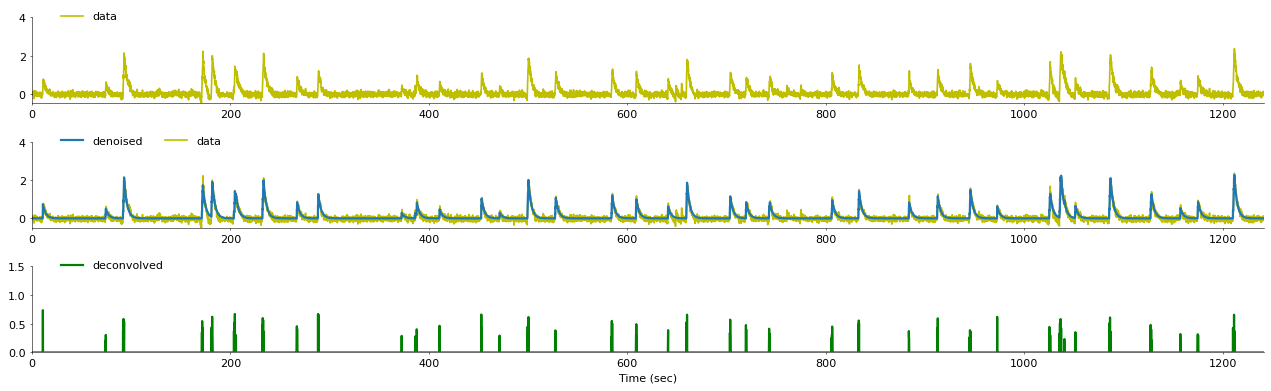

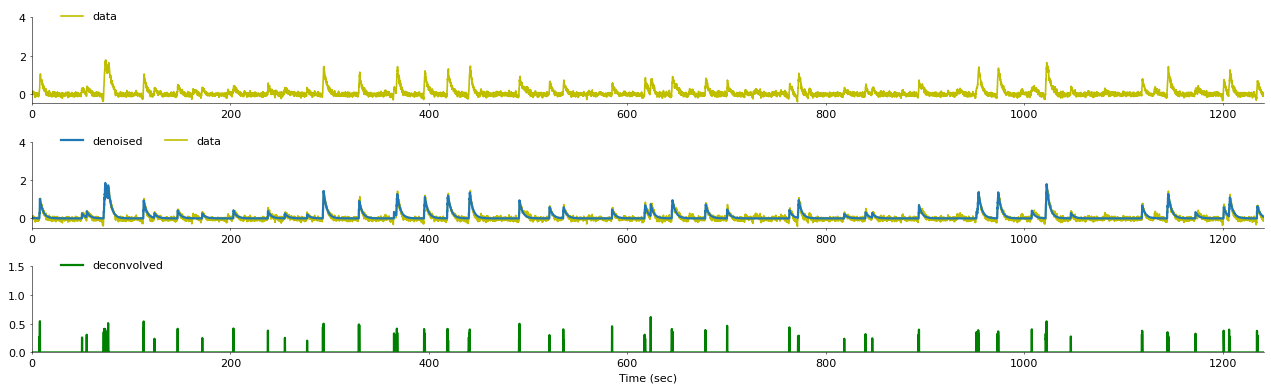

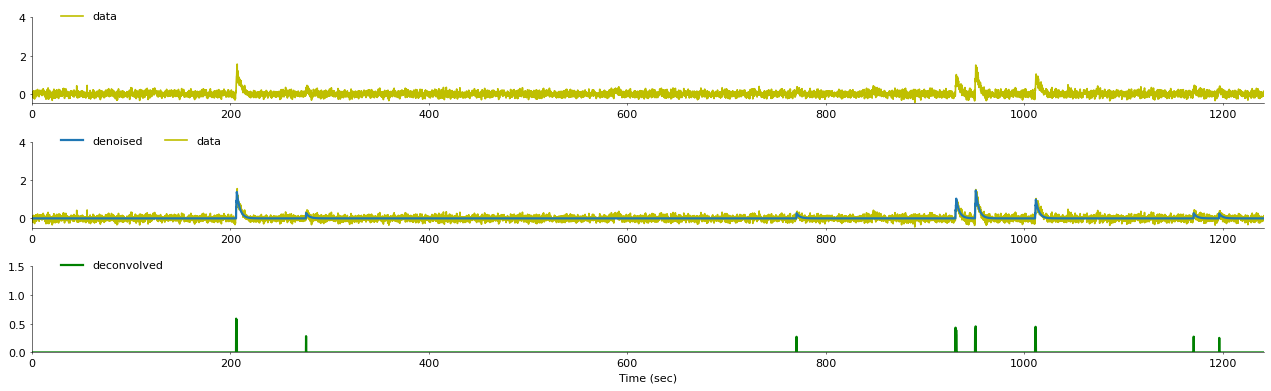

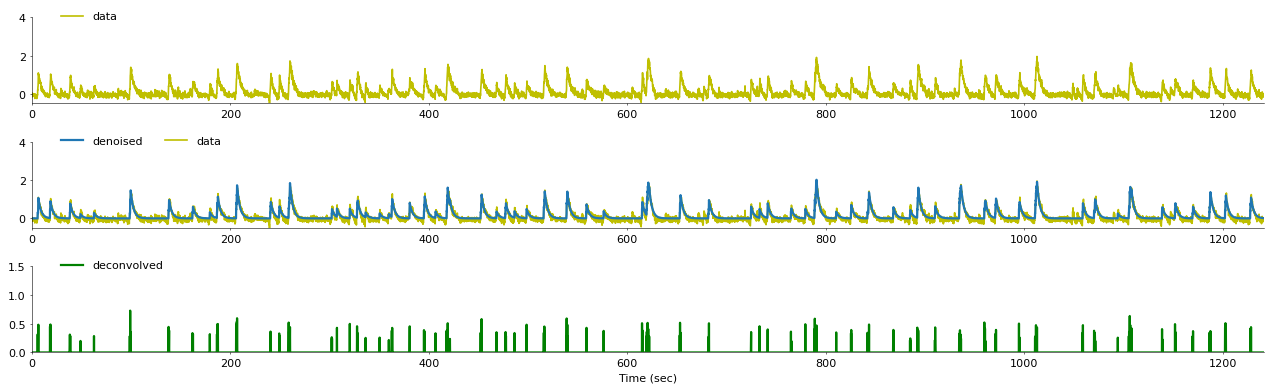

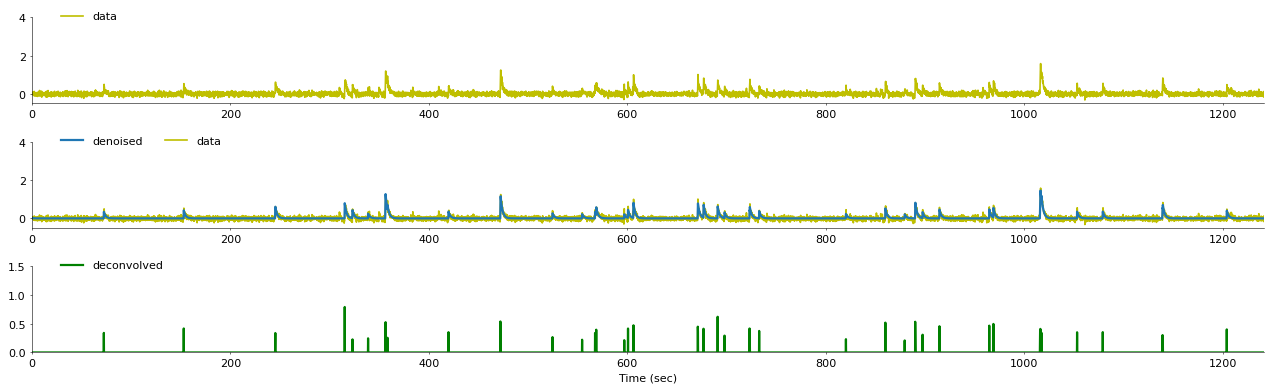

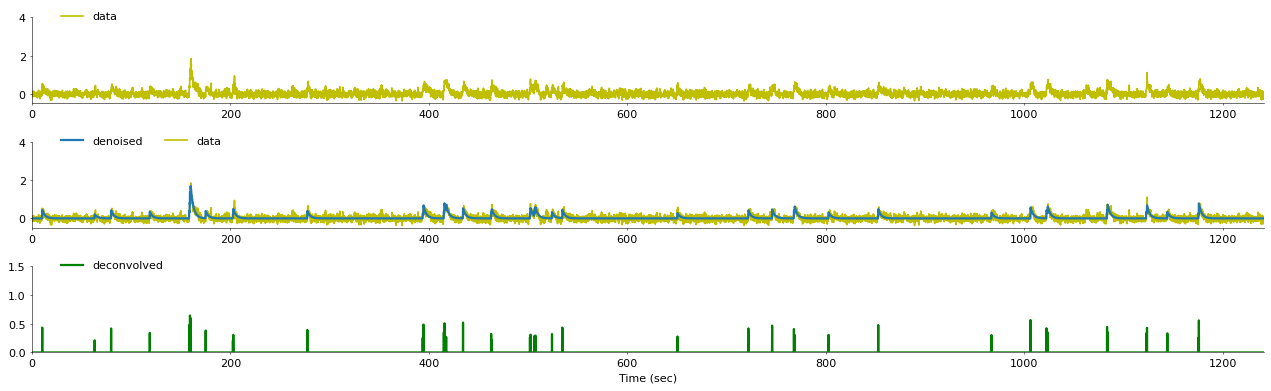

In [20]:
# check parameter before apply oasis in whole data
# cellID = np.random.choice(np.arange(0,corrected_dF_F.shape[0]), size=10, replace=False)
for i in cellID:
    c, s = oasisAR1(corrected_dF_F[i].astype('double'), g=estimate_parameters(corrected_dF_F[i], p=1, lags=200)[0], s_min=0.2)  
    plot_trace(time, corrected_dF_F[i], c, s, xwindow=[time.min(), time.max()])

In [21]:
%%time
denoise = []
deconvo = []
for i in range(corrected_dF_F.shape[0]):
    c, s = oasisAR1(corrected_dF_F[i].astype('double'), g=estimate_parameters(corrected_dF_F[i], p=1, lags=200)[0], s_min=0.2)
    denoise.append(c)
    deconvo.append(s)
denoise=np.array(denoise)
deconvo=np.array(deconvo)

CPU times: user 12.5 s, sys: 924 ms, total: 13.4 s
Wall time: 13.4 s


cell number: 7685


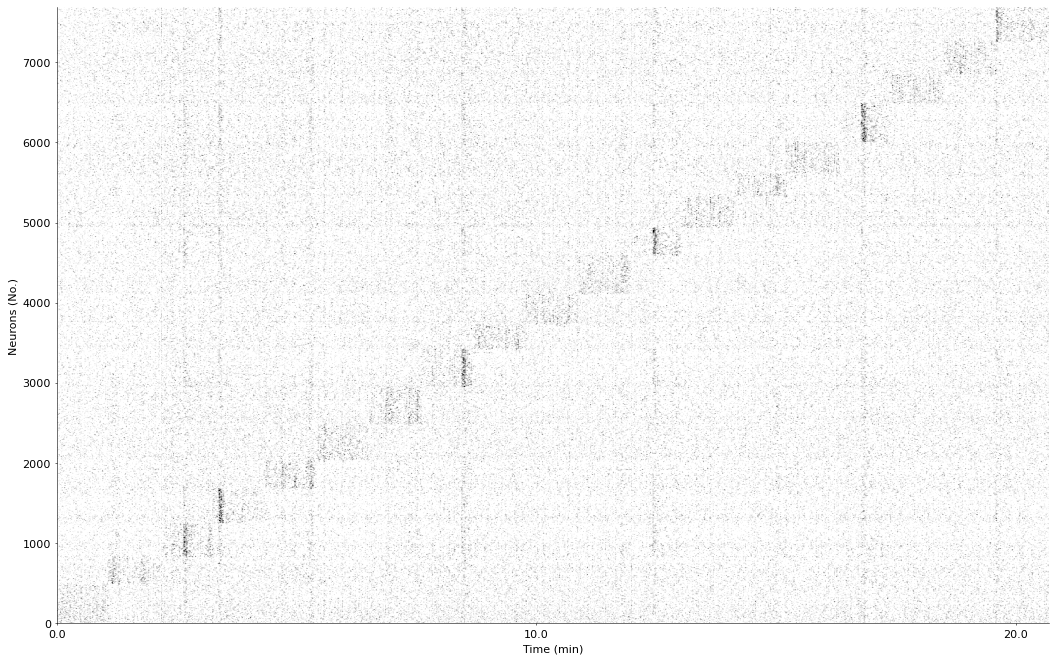

In [22]:
print('cell number:', corrected_dF_F.shape[0])
plt.figure(figsize=(16,10))
plt.imshow(deconvo, vmin = 0, vmax=0.1, aspect='auto', cmap='gray_r')
plt.xlabel('Time (min)')
plt.ylabel('Neurons (No.)')
plt.xlim(0,deconvo.shape[1])
plt.xticks(np.arange(0, deconvo.shape[1], int(600*fs)), np.arange(0, deconvo.shape[1], int(600*fs))/fs/60)
sns.despine()
plt.gca().invert_yaxis()

In [ ]:
with h5py.File(outputDir+'/deconvo.h5', mode='w') as f:
    f.create_dataset('deconvo',data=deconvo)